In [1]:
import sys
!{sys.executable} -m pip install xgboost imbalanced-learn streamlit --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ All imports successful!")

✅ All imports successful!


Shape: (1470, 35)

Attrition Distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     83.9
Yes    16.1
Name: proportion, dtype: float64


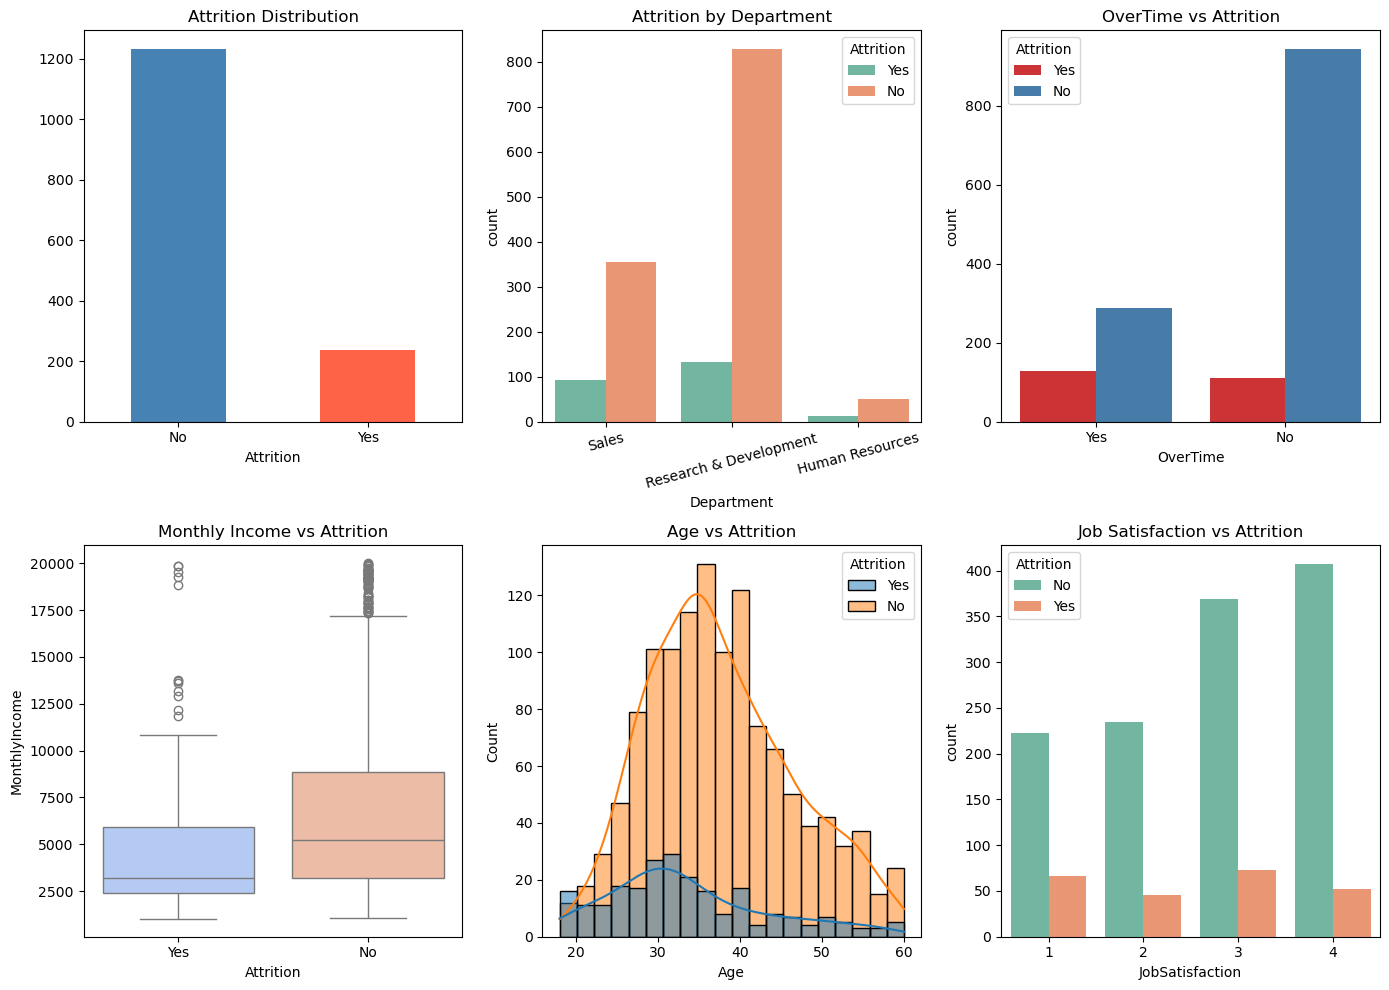

✅ EDA Complete!


In [3]:
df = pd.read_csv("HR-Attrition.csv")

print("Shape:", df.shape)
print("\nAttrition Distribution:")
print(df['Attrition'].value_counts())
print(df['Attrition'].value_counts(normalize=True).mul(100).round(1))

# ── Plot 1: Attrition Distribution ───────────────────────
plt.figure(figsize=(14, 10))

plt.subplot(2, 3, 1)
df['Attrition'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Attrition Distribution')
plt.xticks(rotation=0)

# ── Plot 2: Attrition by Department ──────────────────────
plt.subplot(2, 3, 2)
sns.countplot(data=df, x='Department', hue='Attrition', palette='Set2')
plt.title('Attrition by Department')
plt.xticks(rotation=15)

# ── Plot 3: Attrition by OverTime ────────────────────────
plt.subplot(2, 3, 3)
sns.countplot(data=df, x='OverTime', hue='Attrition', palette='Set1')
plt.title('OverTime vs Attrition')

# ── Plot 4: Monthly Income vs Attrition ──────────────────
plt.subplot(2, 3, 4)
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='coolwarm')
plt.title('Monthly Income vs Attrition')

# ── Plot 5: Age vs Attrition ─────────────────────────────
plt.subplot(2, 3, 5)
sns.histplot(data=df, x='Age', hue='Attrition', bins=20, kde=True)
plt.title('Age vs Attrition')

# ── Plot 6: Job Satisfaction vs Attrition ────────────────
plt.subplot(2, 3, 6)
sns.countplot(data=df, x='JobSatisfaction', hue='Attrition', palette='Set2')
plt.title('Job Satisfaction vs Attrition')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA Complete!")

In [4]:
# ── Drop useless columns ──────────────────────────────────
df.drop(['EmployeeCount', 'Over18', 
         'StandardHours', 'EmployeeNumber'], axis=1, inplace=True)

# ── Encode target ─────────────────────────────────────────
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# ── Encode categoricals ───────────────────────────────────
cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# ── Features & Target ─────────────────────────────────────
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# ── Scale ─────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Split ─────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# ── SMOTE ─────────────────────────────────────────────────
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("✅ Preprocessing done!")
print(f"   Training samples after SMOTE : {len(X_train_res)}")
print(f"   Test samples                 : {len(X_test)}")

✅ Preprocessing done!
   Training samples after SMOTE : 1972
   Test samples                 : 294


In [5]:
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting"   : GradientBoostingClassifier(random_state=42),
    "XGBoost"             : XGBClassifier(eval_metric='logloss', random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    auc    = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    results[name] = auc
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred))
    print(f"  ROC-AUC: {auc:.4f}")

best_name  = max(results, key=results.get)
best_model = models[best_name]
print(f"\n🏆 Best Model: {best_name} (AUC = {results[best_name]:.4f})")


  Logistic Regression
              precision    recall  f1-score   support

           0       0.94      0.77      0.85       247
           1       0.38      0.77      0.51        47

    accuracy                           0.77       294
   macro avg       0.66      0.77      0.68       294
weighted avg       0.86      0.77      0.79       294

  ROC-AUC: 0.8039

  Random Forest
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.60      0.26      0.36        47

    accuracy                           0.85       294
   macro avg       0.74      0.61      0.64       294
weighted avg       0.83      0.85      0.83       294

  ROC-AUC: 0.7945

  Gradient Boosting
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       247
           1       0.58      0.38      0.46        47

    accuracy                           0.86       294
   macro avg       0.74      0.

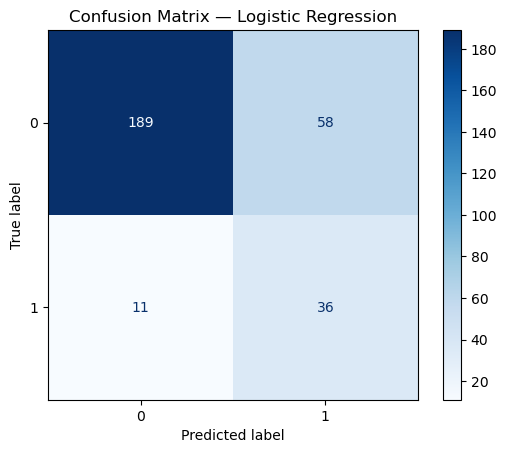

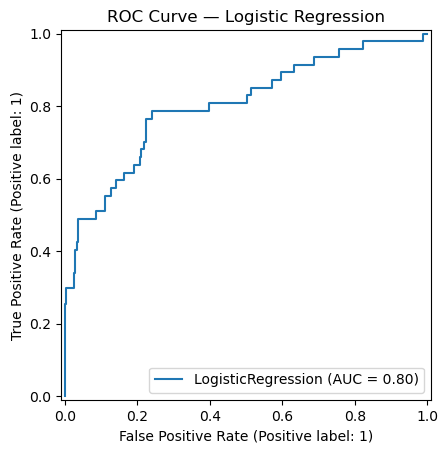

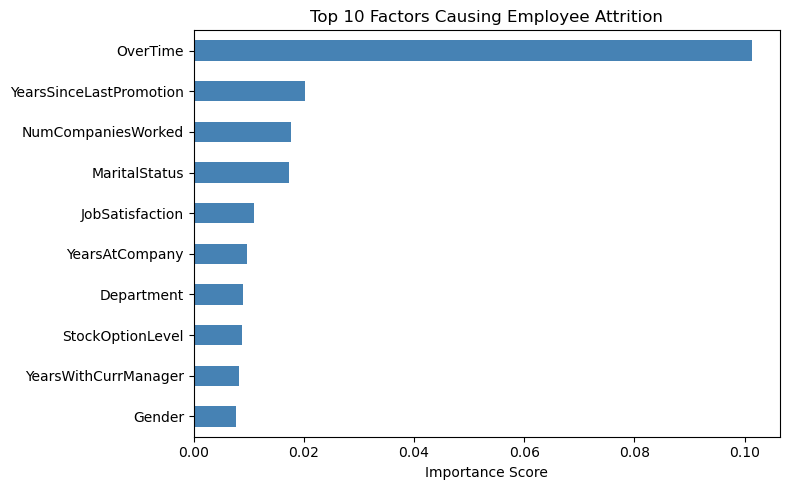


📊 Top Attrition Drivers:
   OverTime                       0.1014
   YearsSinceLastPromotion        0.0202
   NumCompaniesWorked             0.0177
   MaritalStatus                  0.0173
   JobSatisfaction                0.0110
   YearsAtCompany                 0.0097
   Department                     0.0090
   StockOptionLevel               0.0088
   YearsWithCurrManager           0.0083
   Gender                         0.0078


In [7]:
# ── Confusion Matrix ──────────────────────────────────────
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test, cmap='Blues')
plt.title(f'Confusion Matrix — {best_name}')
plt.show()

# ── ROC Curve ─────────────────────────────────────────────
RocCurveDisplay.from_estimator(
    best_model, X_test, y_test)
plt.title(f'ROC Curve — {best_name}')
plt.show()

# ── Feature Importance (works for ALL models) ─────────────
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_model, X_test, y_test, 
    n_repeats=10, random_state=42, scoring='roc_auc')

feat_imp = pd.Series(
    perm.importances_mean, 
    index=X.columns
).nlargest(10)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Top 10 Factors Causing Employee Attrition')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\n📊 Top Attrition Drivers:")
for feat, score in feat_imp.items():
    print(f"   {feat:<30} {score:.4f}")

In [8]:
save_path = r"C:\Users\yadan\OneDrive\Documents\Employee_Attrition_Prediction"

import os
joblib.dump(best_model, os.path.join(save_path, 'attrition_model.pkl'))
joblib.dump(scaler,     os.path.join(save_path, 'scaler.pkl'))
joblib.dump(list(X.columns), os.path.join(save_path, 'features.pkl'))

print("✅ Model saved!")
print("📁 Files:", os.listdir(save_path))

✅ Model saved!
📁 Files: ['.ipynb_checkpoints', 'attrition_model.pkl', 'eda_plots.png', 'features.pkl', 'feature_importance.png', 'HR-Attrition.csv', 'scaler.pkl', 'Untitled.ipynb']


In [9]:
print("=" * 55)
print("   EMPLOYEE ATTRITION PREDICTION — PROJECT SUMMARY")
print("=" * 55)
print(f"\n📁 Dataset     : IBM HR Analytics (1,470 employees)")
print(f"🎯 Target      : Attrition (Yes/No)")
print(f"⚖️  Imbalance   : Handled with SMOTE")
print(f"\n📊 Models Compared:")
for name, auc in results.items():
    flag = " 🏆" if name == best_name else ""
    print(f"   {name:<25} AUC = {auc:.4f}{flag}")
print(f"\n✅ Best Model  : {best_name}")
print(f"📈 ROC-AUC     : {results[best_name]:.4f}")
print("=" * 55)

   EMPLOYEE ATTRITION PREDICTION — PROJECT SUMMARY

📁 Dataset     : IBM HR Analytics (1,470 employees)
🎯 Target      : Attrition (Yes/No)
⚖️  Imbalance   : Handled with SMOTE

📊 Models Compared:
   Logistic Regression       AUC = 0.8039 🏆
   Random Forest             AUC = 0.7945
   Gradient Boosting         AUC = 0.7958
   XGBoost                   AUC = 0.7976

✅ Best Model  : Logistic Regression
📈 ROC-AUC     : 0.8039
